# Задача A. Reinforcement Learning — ATARI

## Игра: Carnival


### Описание игры
Carnival — это «тир». По экрану горизонтально движутся мишени (кролики, утки, совы и др.),
и вы должны стрелять по ним из пушки, которая перемещается влево-вправо.
Запас патронов ограничен — куры могут украсть ваши пули, если вы не собьёте их вовремя.
Награда начисляется **за каждое попадание**

### 6 действий агента:
NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE

## 0

In [1]:
!pip install -q "gymnasium[atari]" ale-py autorom opencv-python-headless
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	C:\Users\maxim\anaconda3\envs\ocrlab\Lib\site-packages\AutoROM\roms

Existing ROMs will be overwritten.


C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\AutoROM\AutoROM.py:264: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1

In [2]:
import numpy as np
import gymnasium as gym
import ale_py
import tensorflow as tf
import collections
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import cv2
import os

gym.register_envs(ale_py)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"CPU threads: auto")

TensorFlow: 2.21.0
Keras: 3.12.1
GPU: []
CPU threads: auto


## 2. Предобработка Atari

In [4]:
class AtariPreprocessing(gym.Wrapper):

    def __init__(self, env, noop_max=30, frame_skip=4, screen_size=84,
                 grayscale=True, stack_frames=4,
                 clip_reward=True, seed=None):
        super().__init__(env)
        self.noop_max = noop_max
        self.frame_skip = frame_skip
        self.screen_size = screen_size
        self.grayscale = grayscale
        self.stack_frames = stack_frames
        self.clip_reward = clip_reward
        self.rng = np.random.default_rng(seed)
        self.frames = collections.deque(maxlen=stack_frames)

        shape = (screen_size, screen_size)
        if grayscale:
            self.observation_space = gym.spaces.Box(
                low=0, high=255, shape=(*shape, stack_frames), dtype=np.uint8
            )
        else:
            self.observation_space = gym.spaces.Box(
                low=0, high=255, shape=(*shape, 3 * stack_frames), dtype=np.uint8
            )

    def _preprocess_frame(self, frame):
        if self.grayscale:
            gray = np.mean(frame, axis=-1).astype(np.uint8)
            resized = cv2.resize(gray, (self.screen_size, self.screen_size),
                                 interpolation=cv2.INTER_AREA)
            return resized
        else:
            resized = cv2.resize(frame, (self.screen_size, self.screen_size),
                                 interpolation=cv2.INTER_AREA)
            return resized

    def _get_stacked(self):
        return np.concatenate(list(self.frames), axis=-1)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        noops = self.rng.integers(1, self.noop_max + 1)
        for _ in range(noops):
            obs, _, terminated, truncated, info = self.env.step(0)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        frame = self._preprocess_frame(obs)
        if self.grayscale:
            frame = frame[..., np.newaxis]
        for _ in range(self.stack_frames):
            self.frames.append(frame)
        return self._get_stacked(), info

    def step(self, action):
        total_reward = 0.0
        terminated = False
        truncated = False
        info = {}
        for _ in range(self.frame_skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        frame = self._preprocess_frame(obs)
        if self.grayscale:
            frame = frame[..., np.newaxis]
        self.frames.append(frame)
        if self.clip_reward:
            total_reward = np.sign(total_reward)
        done = terminated
        return self._get_stacked(), total_reward, done, truncated, info

## 3. Создание среды

**CarnivalNoFrameskip-v4** — 6 действий

Форма наблюдения: (84, 84, 4)
Количество действий: 6


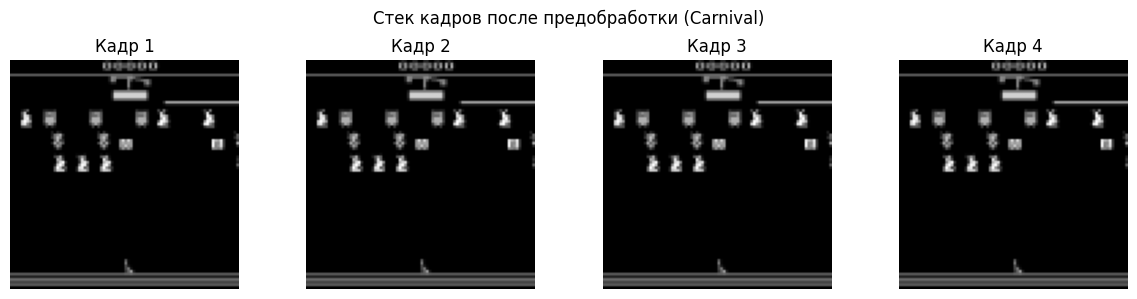

In [5]:
def make_env(env_name="CarnivalNoFrameskip-v4", seed=42):
    env = gym.make(env_name, render_mode="rgb_array")
    env = AtariPreprocessing(env, seed=seed)
    return env

env = make_env()
n_actions = int(env.action_space.n)
obs_shape = env.observation_space.shape
print(f"Форма наблюдения: {obs_shape}")
print(f"Количество действий: {n_actions}")

obs, _ = env.reset()
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(obs[:, :, i], cmap='gray')
    axes[i].set_title(f'Кадр {i+1}')
    axes[i].axis('off')
plt.suptitle('Стек кадров после предобработки (Carnival)')
plt.tight_layout()
plt.show()

## 4. Буфер воспроизведения (Replay Buffer)


In [6]:
class ReplayBuffer:

    def __init__(self, max_size: int, observation_space: gym.spaces.Space,
                 action_space: gym.spaces.Space, seed: int | None = None):
        """Stores the replay history with a maximum of `max_size` entries,
        removing old entries as needed.

        Parameters:
            max_size: maximal number of entries to keep
            observation_space: specification of the observation space
            action_space: specification of the action space
            seed: seed to initialize the internal random number generator for reproducibility
        """
        self.max_size = max_size
        self.rng = np.random.default_rng(seed)
        self.pos = 0
        self.size = 0
        obs_shape = observation_space.shape
        self.observations = np.zeros((max_size, *obs_shape), dtype=np.uint8)
        self.next_observations = np.zeros((max_size, *obs_shape), dtype=np.uint8)
        self.actions = np.zeros(max_size, dtype=np.int32)
        self.rewards = np.zeros(max_size, dtype=np.float32)
        self.dones = np.zeros(max_size, dtype=np.float32)

    def add(self, current_observation: np.ndarray, action: int, reward: float,
            next_observation: np.ndarray, done: bool) -> None:
        """Add a new entry to the buffer.

        Parameters:
            current_observation: environment state observed at the current step
            action: action taken by the model
            reward: reward received after taking the action
            next_observation: environment state observed after taking the action
            done: whether the episode has ended or not
        """
        self.observations[self.pos] = current_observation
        self.actions[self.pos] = action
        self.rewards[self.pos] = reward
        self.next_observations[self.pos] = next_observation
        self.dones[self.pos] = float(done)
        self.pos = (self.pos + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, n_samples: int, replace: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Randomly samples `n_samples` from the buffer.

        Parameters:
            n_samples: number of samples to select
            replace: sample with or without replacement

        Returns:
            current observations, actions, rewards, next observations, done
        """
        indices = self.rng.choice(self.size, size=n_samples, replace=replace)
        return (
            self.observations[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_observations[indices],
            self.dones[indices],
        )

    def clear(self) -> None:
        """Clears the buffer."""
        self.pos = 0
        self.size = 0

    def __getitem__(self, index: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Gets a sample at `index`."""
        assert 0 <= index < self.size
        return (
            self.observations[index], self.actions[index],
            self.rewards[index], self.next_observations[index],
            self.dones[index],
        )

    def __len__(self) -> int:
        """Returns the number of entries in the buffer."""
        return self.size

buffer = ReplayBuffer(max_size=150_000, observation_space=env.observation_space,
                       action_space=env.action_space, seed=42)
print(f"Буфер создан. Размер: {buffer.max_size:,}")
print(f"Расход RAM: {2 * buffer.max_size * np.prod(obs_shape) / 1e9:.1f} ГБ")

Буфер создан. Размер: 150,000
Расход RAM: 8.5 ГБ


## 5. Модель

In [7]:
def build_dqn(input_shape, n_actions, name="dqn"):
    n_actions = int(n_actions)
    inputs = tf.keras.Input(shape=input_shape, dtype=tf.uint8)
    x = tf.keras.layers.Rescaling(scale=1.0 / 255.0)(inputs)
    x = tf.keras.layers.Conv2D(32, 8, strides=4, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Conv2D(64, 4, strides=2, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Conv2D(64, 3, strides=1, activation='relu',
                                kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation='relu',
                               kernel_initializer='he_normal')(x)
    q_values = tf.keras.layers.Dense(n_actions, activation=None,
                                      kernel_initializer='he_normal')(x)
    model = tf.keras.Model(inputs=inputs, outputs=q_values, name=name)
    return model

model = build_dqn(obs_shape, n_actions, name="online")
target_model = build_dqn(obs_shape, n_actions, name="target")
target_model.set_weights(model.get_weights())
model.summary()

test_out = model(np.expand_dims(obs, axis=0), training=False)
print(f"\nФорма выхода: {test_out.shape}")
print(f"Q-значения: {test_out.numpy()[0]}")

Model: "online"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 84, 84, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 84, 84, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 20, 20, 32)          │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 9, 9, 64)            │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,606,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           3,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,687,206 (6.44 MB)

 Trainable params: 1,687,206 (6.44 MB)

 Non-trainable params: 0 (0.00 B)


Форма выхода: (1, 6)
Q-значения: [-0.08477073 -0.00263644 -0.05134835 -0.20501862 -0.2200456  -0.16668576]


## 6. Sampler

In [ ]:
class Sampler:

    def __init__(self, epsilon: float, seed: int | None = None):
        """Selects a random action with probability `epsilon` otherwise selects
        the most probable action given by the model.

        Parameters:
            epsilon: the probability to select a random action
            seed: seed to initialize the internal random number generator for reproducibility
        """
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

    def __call__(self, q_values: np.ndarray) -> int:
        """Select an action given the Q-values.

        Parameters:
            q_values: Q-value estimates for each action (1D array)

        Returns:
            index of the selected action
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, len(q_values)))
        return int(np.argmax(q_values))

In [8]:
class Sampler:

    def __init__(self, epsilon: float, seed: int | None = None):
        """Selects a random action with probability `epsilon` otherwise selects
        the most probable action given by the model.

        Parameters:
            epsilon: the probability to select a random action
            seed: seed to initialize the internal random number generator for reproducibility
        """
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)

    def __call__(self, q_values: np.ndarray) -> int:
        """Select an action given the Q-values.

        Parameters:
            q_values: Q-value estimates for each action (1D array)

        Returns:
            index of the selected action
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, len(q_values)))
        return int(np.argmax(q_values))

sampler = Sampler(epsilon=1.0, seed=42)
test_q = np.random.randn(6)
actions_chosen = [sampler(test_q) for _ in range(600)]
print("Случайный (eps=1.0):", {a: actions_chosen.count(a) for a in range(6)})
# print("Жадный (eps=0.0):", Sampler(0.0, 42)(test_q))

Случайный (eps=1.0): {0: 106, 1: 102, 2: 93, 3: 92, 4: 100, 5: 107}
Жадный (eps=0.0): 2


## 7. Функция игры

In [10]:
def play_game(model: tf.keras.Model, buffer: ReplayBuffer | None,
              env: gym.Env, max_steps: int, sampler: Sampler,
              observation: np.ndarray | None = None):
    """Play game and record transitions to replay buffer.

    Parameters:
        model: the model to get actions with
        buffer: replay buffer to store the entries to
        env: environment to play
        max_steps: maximal number of steps to perform
        sampler: sampler to use to sample actions
        observation: the observation to resume from

    Returns:
        the last observation, total_reward, steps_played
    """
    if observation is None:
        observation, _ = env.reset()
    total_reward = 0.0
    steps = 0
    for _ in range(max_steps):
        obs_tensor = np.expand_dims(observation, axis=0)
        q_values = predict_q(obs_tensor)
        if hasattr(q_values, 'numpy'):
            q_values = q_values.numpy()[0]
        else:
            q_values = np.array(q_values)[0]
        action = sampler(q_values)
        next_observation, reward, done, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        if buffer is not None:
            buffer.add(observation, action, reward, next_observation, done or truncated)
        if done or truncated:
            observation, _ = env.reset()
        else:
            observation = next_observation
    return observation, total_reward, steps

## 8. Double Q-Learning Loss

### Double DQN:

1. **Online-сеть** выбирает лучшее действие
2. **Target-сеть** оценивает это действие

In [11]:
@tf.function
def qq_loss(
    current_observation: tf.Tensor,
    action: tf.Tensor,
    reward: tf.Tensor,
    next_observation: tf.Tensor,
    done: tf.Tensor,
    model: tf.keras.Model,
    target_model: tf.keras.Model,
    gamma: float
) -> tf.Tensor:
    """Computes double q learning loss.

    Parameters:
        current_observation: observations at the current time step (B, 84, 84, 4)
        action: actions taken at the current time step (B,)
        reward: rewards at the current time step (B,)
        next_observation: observations at the next time step (B, 84, 84, 4)
        done: whether the episode has ended or not (B,)
        model: training model (online)
        target_model: target model
        gamma: discount factor

    Returns:
        Computed loss (scalar)
    """
    q_values = model(current_observation, training=True)
    n_actions = tf.shape(q_values)[-1]
    action_indices = tf.cast(action, tf.int32)
    action_mask = tf.one_hot(action_indices, n_actions, dtype=tf.float32)
    q_selected = tf.reduce_sum(q_values * action_mask, axis=-1)

    next_q_online = model(next_observation, training=False)
    best_next_actions = tf.cast(tf.argmax(next_q_online, axis=-1), tf.int32)

    next_q_target = target_model(next_observation, training=False)
    best_action_mask = tf.one_hot(best_next_actions, n_actions, dtype=tf.float32)
    next_q_selected = tf.reduce_sum(next_q_target * best_action_mask, axis=-1)

    td_target = reward + gamma * next_q_selected * (1.0 - done)
    td_target = tf.stop_gradient(td_target) # градиент не должен проходить через таргет, обновляем только предсказание Q(s,a), а таргет y фиксирован. 
                                            # Без stop_gradient обучение расходится.
    loss = tf.keras.losses.huber(td_target, q_selected)
    return tf.reduce_mean(loss)

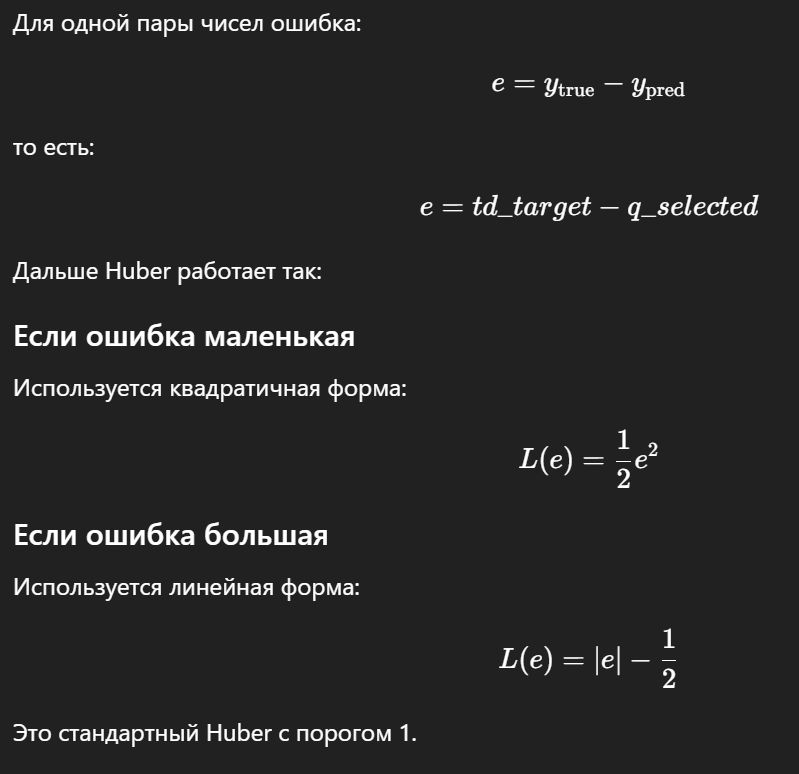

In [12]:
# Тест
dummy_obs = np.random.randint(0, 255, size=(4, *obs_shape), dtype=np.uint8)
dummy_act = np.array([0, 1, 2, 3], dtype=np.int32)
dummy_rew = np.array([1.0, 0.0, -1.0, 1.0], dtype=np.float32)
dummy_next = np.random.randint(0, 255, size=(4, *obs_shape), dtype=np.uint8)
dummy_done = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
test_loss = qq_loss(tf.constant(dummy_obs), tf.constant(dummy_act),
    tf.constant(dummy_rew), tf.constant(dummy_next),
    tf.constant(dummy_done), model, target_model, gamma=0.99)
print(f"Тестовый лосс: {test_loss.numpy():.4f} ✓")

Тестовый лосс: 0.9491 ✓


## 9. Обучение

In [13]:
BUFFER_SIZE      = 150_000
BATCH_SIZE       = 32
LEARNING_RATE    = 1e-4
GAMMA            = 0.99
EPS_START        = 1.0
EPS_END          = 0.1
EPS_DECAY_STEPS  = 150_000
TARGET_UPDATE    = 1_000
LEARNING_STARTS  = 10_000
TOTAL_STEPS      = 1_500_000
EVAL_EVERY       = 75_000
TRAIN_FREQ       = 4

env = make_env(seed=42)
model = build_dqn(obs_shape, n_actions, name="online")
target_model = build_dqn(obs_shape, n_actions, name="target")
target_model.set_weights(model.get_weights())

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=10.0)
buffer = ReplayBuffer(BUFFER_SIZE, env.observation_space, env.action_space, seed=42)
sampler = Sampler(epsilon=EPS_START, seed=42)

# Компилированная функция предсказания — ускоряет инференс на CPU
@tf.function
def predict_q(obs):
    return model(obs, training=False)

print(f"Среда: CarnivalNoFrameskip-v4 | Действий: {n_actions}")
print(f"Обучение: {TOTAL_STEPS:,} шагов | TRAIN_FREQ: {TRAIN_FREQ}")
print(f"Буфер: {BUFFER_SIZE:,} (~{2*BUFFER_SIZE*np.prod(obs_shape)/1e9:.1f} ГБ RAM)")

Среда: CarnivalNoFrameskip-v4 | Действий: 6
Обучение: 1,500,000 шагов | TRAIN_FREQ: 4
Буфер: 150,000 (~8.5 ГБ RAM)


In [ ]:
@tf.function
def train_step(b_obs, b_act, b_rew, b_next, b_done):
    with tf.GradientTape() as tape:
        loss = qq_loss(b_obs, b_act, b_rew, b_next, b_done,
                       model, target_model, GAMMA)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [14]:
episode_rewards = []
episode_reward = 0.0
eval_rewards = []
losses = []
best_eval_reward = -float('inf')

observation, _ = env.reset()
start_time = time.time()

for step in range(1, TOTAL_STEPS + 1):
    # Линейный decay epsilon
    frac = min(1.0, step / EPS_DECAY_STEPS)
    sampler.epsilon = EPS_START + frac * (EPS_END - EPS_START)

    # Выбор действия (через компилированную функцию)
    obs_tensor = np.expand_dims(observation, axis=0)
    q_values = predict_q(obs_tensor)
    if hasattr(q_values, 'numpy'):
        q_values = q_values.numpy()[0]
    else:
        q_values = np.array(q_values)[0]
    action = sampler(q_values)

    # Шаг среды
    next_observation, reward, done, truncated, info = env.step(action)
    episode_reward += reward
    buffer.add(observation, action, reward, next_observation, done or truncated)

    if done or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0.0
        observation, _ = env.reset()
    else:
        observation = next_observation

    # Обучение (каждые TRAIN_FREQ = 4 шагов)
    if step >= LEARNING_STARTS and step % TRAIN_FREQ == 0:
        batch = buffer.sample(BATCH_SIZE)
        b_obs = tf.constant(batch[0], dtype=tf.uint8)
        b_act = tf.constant(batch[1], dtype=tf.int32)
        b_rew = tf.constant(batch[2], dtype=tf.float32)
        b_next = tf.constant(batch[3], dtype=tf.uint8)
        b_done = tf.constant(batch[4], dtype=tf.float32)
        loss = train_step(b_obs, b_act, b_rew, b_next, b_done)
        losses.append(float(loss))

    # Обновление target-сети каждые 10000
    if step % TARGET_UPDATE == 0:
        target_model.set_weights(model.get_weights())

    if step % 10_000 == 0:
        elapsed = time.time() - start_time
        avg_r = np.mean(episode_rewards[-20:]) if episode_rewards else 0.0
        avg_l = np.mean(losses[-1000:]) if losses else 0.0
        fps = step / elapsed if elapsed > 0 else 0
        eta_minutes = (TOTAL_STEPS - step) / fps / 60 if fps > 0 else 0
        print(f"Шаг {step:>7,}/{TOTAL_STEPS:,} | "
              f"Eps: {sampler.epsilon:.3f} | "
              f"Награда (20 эп): {avg_r:>7.1f} | "
              f"Лосс: {avg_l:.4f} | "
              f"FPS: {fps:.0f} | "
              f"Осталось: ~{eta_minutes:.0f} мин")

    # Оценка
    if step % EVAL_EVERY == 0:
        eval_env = make_env(seed=123)
        eval_sampler = Sampler(epsilon=0.05, seed=123)
        eval_obs, _ = eval_env.reset()
        eval_total = 0.0
        for _ in range(10_000):
            eq = predict_q(np.expand_dims(eval_obs, 0))
            if hasattr(eq, 'numpy'):
                eq = eq.numpy()[0]
            else:
                eq = np.array(eq)[0]
            ea = eval_sampler(eq)
            eval_obs, er, ed, et, _ = eval_env.step(ea)
            eval_total += er
            if ed or et:
                break
        eval_rewards.append((step, eval_total))
        print(f"  >> ОЦЕНКА: {eval_total:.1f}")
        if eval_total > best_eval_reward:
            best_eval_reward = eval_total
            model.save('carnival_best_model.keras')
            print(f"  :::: Новый лучший результат! Модель сохранена.")
        eval_env.close()

total_time = time.time() - start_time
print(f"\nEnd! Время: {total_time/60:.1f} мин ({total_time/3600:.1f} ч)")
print(f"Эпизодов: {len(episode_rewards)} | Лучшая оценка: {best_eval_reward:.1f}")

Шаг  10,000/1,500,000 | Eps: 0.940 | Награда (20 эп):    13.1 | Лосс: 0.0833 | FPS: 346 | Осталось: ~72 мин
Шаг  20,000/1,500,000 | Eps: 0.880 | Награда (20 эп):    12.4 | Лосс: 0.0149 | FPS: 230 | Осталось: ~107 мин
Шаг  30,000/1,500,000 | Eps: 0.820 | Награда (20 эп):    11.6 | Лосс: 0.0164 | FPS: 205 | Осталось: ~119 мин
Шаг  40,000/1,500,000 | Eps: 0.760 | Награда (20 эп):    11.4 | Лосс: 0.0174 | FPS: 194 | Осталось: ~125 мин
Шаг  50,000/1,500,000 | Eps: 0.700 | Награда (20 эп):    11.5 | Лосс: 0.0192 | FPS: 189 | Осталось: ~128 мин
Шаг  60,000/1,500,000 | Eps: 0.640 | Награда (20 эп):    12.3 | Лосс: 0.0187 | FPS: 187 | Осталось: ~128 мин
Шаг  70,000/1,500,000 | Eps: 0.580 | Награда (20 эп):    12.2 | Лосс: 0.0197 | FPS: 187 | Осталось: ~128 мин
  >> ОЦЕНКА: 13.0
  :::: Новый лучший результат! Модель сохранена.
Шаг  80,000/1,500,000 | Eps: 0.520 | Награда (20 эп):    11.9 | Лосс: 0.0206 | FPS: 184 | Осталось: ~129 мин
Шаг  90,000/1,500,000 | Eps: 0.460 | Награда (20 эп):    11.8 

## 10. Прогресс обучения

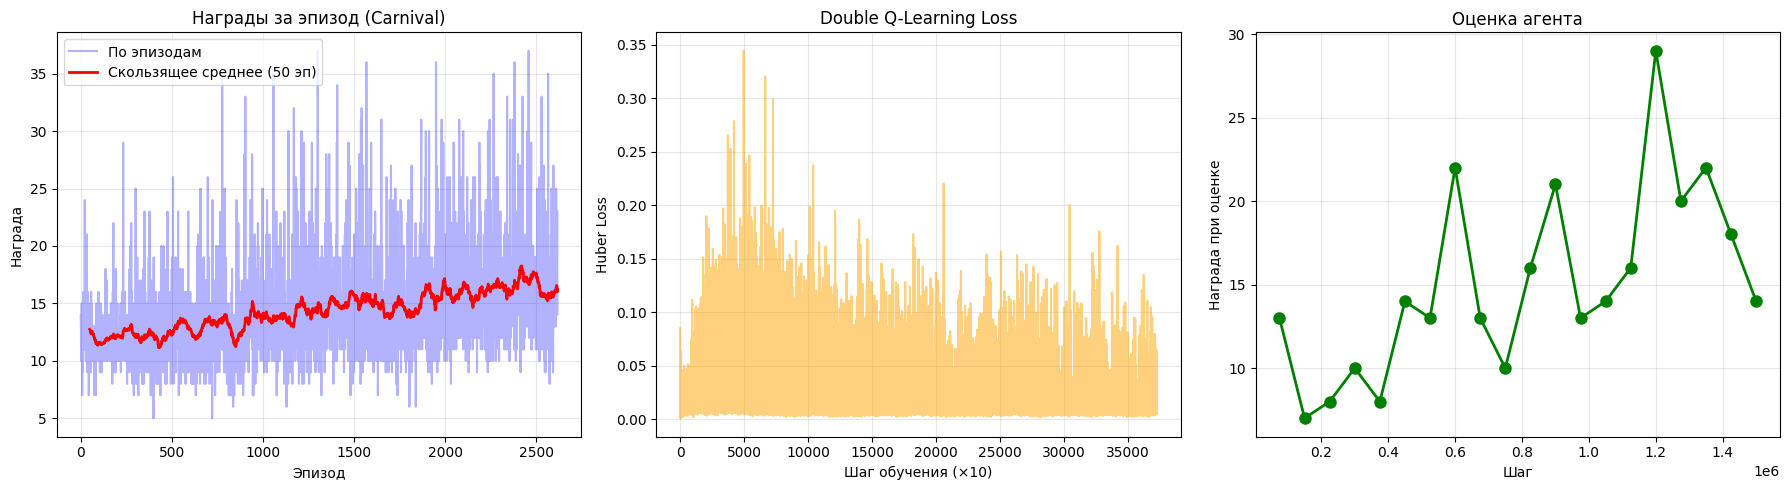

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if episode_rewards:
    axes[0].plot(episode_rewards, alpha=0.3, color='blue', label='По эпизодам')
    window = min(50, len(episode_rewards))
    if window > 1:
        ma = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(episode_rewards)), ma,
                     color='red', linewidth=2, label=f'Скользящее среднее ({window} эп)')
    axes[0].set_xlabel('Эпизод')
    axes[0].set_ylabel('Награда')
    axes[0].set_title('Награды за эпизод (Carnival)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if losses:
    axes[1].plot(losses[::10], alpha=0.5, color='orange')
    axes[1].set_xlabel('Шаг обучения (×10)')
    axes[1].set_ylabel('Huber Loss')
    axes[1].set_title('Double Q-Learning Loss')
    axes[1].grid(True, alpha=0.3)

if eval_rewards:
    steps_e, rewards_e = zip(*eval_rewards)
    axes[2].plot(steps_e, rewards_e, 'o-', color='green', linewidth=2, markersize=8)
    axes[2].set_xlabel('Шаг')
    axes[2].set_ylabel('Награда при оценке')
    axes[2].set_title('Оценка агента')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress_carnival.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Сохранение модели

In [16]:
model.save('carnival_ddqn_final.keras')
print("Финальная модель: carnival_ddqn_final.keras")
print(f"Лучшая модель: carnival_best_model.keras (награда: {best_eval_reward:.1f})")

Финальная модель: carnival_ddqn_final.keras
Лучшая модель: carnival_best_model.keras (награда: 29.0)


## 12. Тестирование

Сравниваем обученного агента со случайным.

In [17]:
# Загрузка лучшей модели
if os.path.exists('carnival_best_model.keras'):
    model = tf.keras.models.load_model('carnival_best_model.keras')
    print("Загружена лучшая модель")
else:
    print("Используется финальная модель")

# Обновляем predict_q для загруженной модели
@tf.function
def predict_q(obs):
    return model(obs, training=False)

def evaluate_agent(model, env_name="CarnivalNoFrameskip-v4", n_episodes=10,
                   epsilon=0.01, seed=0, max_steps=10_000):
    eval_env = make_env(env_name, seed=seed)
    eval_sampler = Sampler(epsilon=epsilon, seed=seed)
    rewards = []
    for ep in range(n_episodes):
        obs, _ = eval_env.reset()
        total_reward = 0.0
        for step in range(max_steps):
            q = predict_q(np.expand_dims(obs, 0))
            if hasattr(q, 'numpy'):
                q = q.numpy()[0]
            else:
                q = np.array(q)[0]
            action = eval_sampler(q)
            obs, reward, done, truncated, _ = eval_env.step(action)
            total_reward += reward
            if done or truncated:
                break
        rewards.append(total_reward)
        print(f"  Эпизод {ep+1}/{n_episodes}: награда = {total_reward:.1f}")
    eval_env.close()
    print(f"\nСредняя награда: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    return rewards

Загружена лучшая модель


In [35]:
print("Случайный агент")
random_sampler = Sampler(epsilon=1.0, seed=0)
random_env = make_env(seed=0)
random_rewards = []
for ep in range(10):
    obs_r, _ = random_env.reset()
    total = 0.0
    for _ in range(10_000):
        action = random_sampler(np.zeros(n_actions))
        obs_r, r, done, trunc, _ = random_env.step(action)
        total += r
        if done or trunc:
            break
    random_rewards.append(total)
    print(f"  Эпизод {ep+1}: {total:.0f}")
random_env.close()
print(f"\nСлучайный: {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")

print("\nОбученный агент")
test_rewards = evaluate_agent(model, n_episodes=10, epsilon=0.01)

print("\n" + ":"*50)
print("СРАВНЕНИЕ")
print(":"*50)
print(f"Случайный агент:  {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print(f"Обученный агент:  {np.mean(test_rewards):.1f} ± {np.std(test_rewards):.1f}")
improvement = np.mean(test_rewards) - np.mean(random_rewards)
print(f"Улучшение:        {improvement:+.1f}")
if improvement > np.std(random_rewards):
    print("\n Агент значительно лучше случайного")
elif improvement > 0:
    print("\n Агент немного лучше случайного")
else:
    print("\n Агент не лучше случайного")

Случайный агент
  Эпизод 1: 14
  Эпизод 2: 11
  Эпизод 3: 14
  Эпизод 4: 9
  Эпизод 5: 12
  Эпизод 6: 12
  Эпизод 7: 9
  Эпизод 8: 12
  Эпизод 9: 14
  Эпизод 10: 14

Случайный: 12.1 ± 1.9

Обученный агент
  Эпизод 1/10: награда = 26.0
  Эпизод 2/10: награда = 17.0
  Эпизод 3/10: награда = 16.0
  Эпизод 4/10: награда = 10.0
  Эпизод 5/10: награда = 15.0
  Эпизод 6/10: награда = 15.0
  Эпизод 7/10: награда = 17.0
  Эпизод 8/10: награда = 26.0
  Эпизод 9/10: награда = 11.0
  Эпизод 10/10: награда = 26.0

Средняя награда: 17.90 ± 5.73

::::::::::::::::::::::::::::::::::::::::::::::::::
СРАВНЕНИЕ
::::::::::::::::::::::::::::::::::::::::::::::::::
Случайный агент:  12.1 ± 1.9
Обученный агент:  17.9 ± 5.7
Улучшение:        +5.8

 Агент значительно лучше случайного


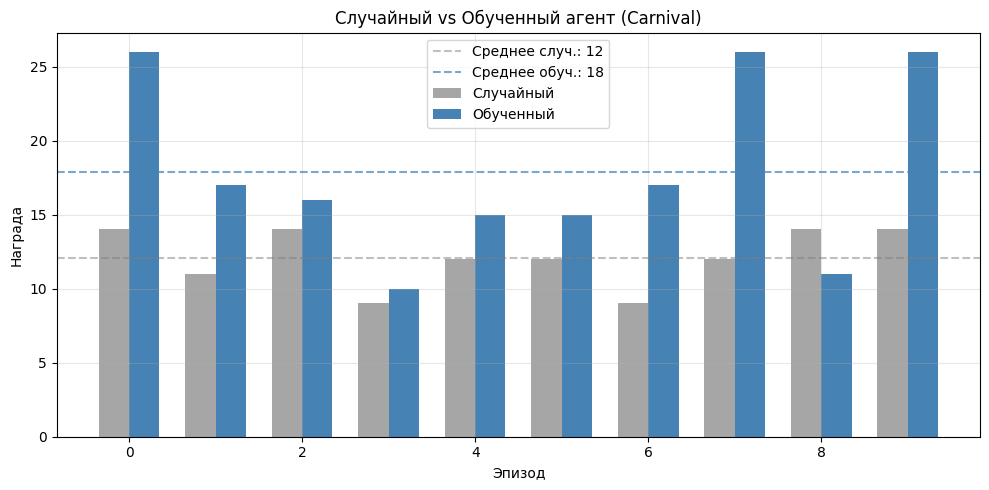

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(10)
width = 0.35
ax.bar(x - width/2, random_rewards, width, label='Случайный', color='gray', alpha=0.7)
ax.bar(x + width/2, test_rewards, width, label='Обученный', color='steelblue')
ax.axhline(y=np.mean(random_rewards), color='gray', linestyle='--', alpha=0.5,
           label=f'Среднее случ.: {np.mean(random_rewards):.0f}')
ax.axhline(y=np.mean(test_rewards), color='steelblue', linestyle='--', alpha=0.7,
           label=f'Среднее обуч.: {np.mean(test_rewards):.0f}')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Награда')
ax.set_title('Случайный vs Обученный агент (Carnival)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Запись видео

In [32]:
def record_game(model, env_name="CarnivalNoFrameskip-v4", max_steps=5000,
                epsilon=0.01, seed=11):
    rec_env = gym.make(env_name, render_mode="rgb_array")
    rec_env = AtariPreprocessing(rec_env, seed=seed)
    rec_sampler = Sampler(epsilon=epsilon, seed=seed)
    frames = []
    obs, _ = rec_env.reset()
    total_reward = 0.0
    for step in range(max_steps):
        raw_frame = rec_env.env.render()
        if raw_frame is not None:
            frames.append(raw_frame)
        q = predict_q(np.expand_dims(obs, 0))
        if hasattr(q, 'numpy'):
            q = q.numpy()[0]
        else:
            q = np.array(q)[0]
        action = rec_sampler(q)
        obs, reward, done, truncated, _ = rec_env.step(action)
        total_reward += reward
        if done or truncated:
            break
    rec_env.close()
    print(f"Записано {len(frames)} кадров, награда = {total_reward:.1f}")
    return frames, total_reward

print("Запись видео...")
frames, video_reward = record_game(model)

Запись видео...
Записано 917 кадров, награда = 21.0


In [33]:
from matplotlib import animation
from IPython.display import HTML

if frames:
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.axis('off')
    ax.set_title('Carnival — обученный агент')
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return [im]
    step_size = max(1, len(frames) // 200)
    anim = animation.FuncAnimation(fig, update,
                                    frames=range(0, len(frames), step_size),
                                    interval=50, blit=True)
    plt.close()
    display(HTML(anim.to_jshtml()))
else:
    print("Кадры не записаны.")

In [34]:
# Сохранение GIF
if frames:
    try:
        fig2, ax2 = plt.subplots(figsize=(5, 7))
        ax2.axis('off')
        im2 = ax2.imshow(frames[0])
        def update2(i):
            im2.set_data(frames[i])
            return [im2]
        step_size = max(1, len(frames) // 200)
        anim2 = animation.FuncAnimation(fig2, update2,
                                         frames=range(0, len(frames), step_size),
                                         interval=50, blit=True)
        plt.close()
        anim2.save('carnival_gameplay.gif', writer='pillow', fps=30)
        print("GIF сохранён: carnival_gameplay.gif")
    except Exception as e:
        print(f"Не удалось сохранить GIF: {e}")

GIF сохранён: carnival_gameplay.gif
